Dataset Link: [Smart Meters in London on Kaggle](https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london)

🧠 FINAL DESIGN

This unified pipeline includes:

✅ Consolidation
Efficient loading (no temp files)
Data audit
Outlier handling

✅ Preprocessing
Daily aggregation
Weather + holiday integration
Temporal continuity enforcement

✅ Clustering
MinMax scaling
Elbow + silhouette
Interpretable regimes

✅ Forecasting
SARIMAX (with diagnostics)
LSTM (clean supervised approach)

✅ Evaluation
RMSE, MAE, R²
Residual diagnostics

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The Google Drive was successfully mounted, allowing access to files stored in Drive.

🔹 Step 1: Load & Consolidate

In [48]:
import pandas as pd
import numpy as np
import glob, os

# Load energy blocks
path = '/content/drive/MyDrive/SMDATA/daily_dataset/'

# Check if the directory exists
if not os.path.exists(path):
    print(f"Error: Directory not found at {path}")
else:
    files = sorted(glob.glob(os.path.join(path, 'block_*.csv')))
    if not files:
        print(f"Error: No 'block_*.csv' files found in {path}")
        print("Please ensure the dataset is correctly placed in your Google Drive.")
        energy = pd.DataFrame() # Initialize an empty DataFrame to avoid further errors
    else:
        dfs = [pd.read_csv(f, usecols=['day','LCLid','energy_sum']) for f in files]
        energy = pd.concat(dfs, ignore_index=True)

        # Convert date
        energy['day'] = pd.to_datetime(energy['day'])

        print(f"Energy shape: {energy.shape}")

Energy shape: (3510433, 3)


The energy data from all block files was successfully loaded and concatenated into a single DataFrame. The resulting DataFrame has 3,510,433 rows and 3 columns, with the 'day' column converted to datetime objects.

🔹 2. DATA CLEANING & OUTLIERS

In [49]:
# Missing values
energy = energy.ffill()

# Outlier removal (3 std)
mean = energy['energy_sum'].mean()
std = energy['energy_sum'].std()

energy = energy[(energy['energy_sum'] > mean - 3*std) &
                (energy['energy_sum'] < mean + 3*std)]

Missing values in the 'energy_sum' column were forward-filled, and outliers (values beyond 3 standard deviations from the mean) were removed from the 'energy_sum' column, enhancing data quality for analysis.

🔹 3. DAILY AGGREGATION

In [50]:
energy_daily = energy.groupby('day').agg({
    'energy_sum':'sum',
    'LCLid':'nunique'
}).reset_index()

energy_daily['avg_energy'] = energy_daily['energy_sum'] / energy_daily['LCLid']

The energy data was aggregated daily, summing up 'energy_sum' and counting unique 'LCLid' values. A new column 'avg_energy' was calculated, representing the average energy consumption per household per day.

🔹 4. LOAD WEATHER + CLEAN

In [51]:
weather = pd.read_csv('/content/drive/MyDrive/SMDATA/weather_daily_darksky.csv')

weather['day'] = pd.to_datetime(weather['time']).dt.normalize()

weather = weather[['day','temperatureMax','humidity','windSpeed',
                   'dewPoint','cloudCover','visibility','uvIndex']]

weather = weather.interpolate()
weather = weather.groupby('day').mean().reset_index()

Daily weather data was loaded, 'time' was converted to 'day' (datetime) and normalized. Irrelevant columns were dropped, missing values were interpolated, and daily averages were computed for each weather variable.

🔹 5. LOAD HOLIDAYS

In [52]:
holiday = pd.read_csv('/content/drive/MyDrive/SMDATA/uk_bank_holidays.csv')
holiday['day'] = pd.to_datetime(holiday['Bank holidays'])
holiday['holiday_ind'] = 1
holiday = holiday[['day','holiday_ind']]

UK bank holiday data was loaded, with 'Bank holidays' converted to 'day' (datetime). A 'holiday_ind' column was created and set to 1 for holiday dates, preparing it for merge.

🔹 6. FINAL MERGE

In [53]:
df = energy_daily.merge(weather, on='day', how='inner')
df = df.merge(holiday, on='day', how='left')
df['holiday_ind'] = df['holiday_ind'].fillna(0)

# Set index
df = df.sort_values('day').set_index('day').asfreq('D').ffill()

print(df.shape)

(829, 11)


The daily energy, weather, and holiday data were successfully merged into a single DataFrame `df`. Missing holiday indicators were filled with 0, and the DataFrame was sorted by date, indexed, and forward-filled to ensure temporal continuity. The final merged DataFrame has 829 rows and 11 columns.

🔹 7. WEATHER CLUSTERING

In [54]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['temperatureMax','humidity','windSpeed']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[features])

# Silhouette check
for k in range(2,6):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    print(f"k={k}, silhouette={silhouette_score(X_scaled, labels):.3f}")

# Final model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['weather_cluster'] = kmeans.fit_predict(X_scaled)

print(df.groupby('weather_cluster')[features].mean())

k=2, silhouette=0.334
k=3, silhouette=0.303
k=4, silhouette=0.263
k=5, silhouette=0.263
                 temperatureMax  humidity  windSpeed
weather_cluster                                     
0                     11.308893  0.773764   5.413358
1                     20.739496  0.694819   2.816915
2                     10.118387  0.855935   2.668710


Weather features were scaled using MinMaxScaler. A silhouette score analysis for k=2 to k=5 showed k=2 had the highest score (0.334), followed by k=3 (0.303). A KMeans model with 3 clusters was then applied, and the mean feature values for each cluster were printed, revealing distinct weather regimes.

🔹 8. SARIMAX MODEL

In [55]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df.iloc[:-30]
test = df.iloc[-30:]

endog = train['avg_energy']
exog = train[['weather_cluster','holiday_ind']]

model = SARIMAX(endog,
                exog=exog,
                order=(7,1,1),
                seasonal_order=(1,1,0,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

res = model.fit(disp=False)

# Forecast
forecast = res.get_forecast(steps=30, exog=test[['weather_cluster','holiday_ind']])
pred = forecast.predicted_mean

The data was split into training and testing sets. A SARIMAX model was fitted using 'avg_energy' as the endogenous variable and 'weather_cluster' and 'holiday_ind' as exogenous variables. The model then generated 30-day forecasts.

🔹 9. SARIMAX EVALUATION

In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

sarimax_rmse = np.sqrt(mean_squared_error(test['avg_energy'], pred))
sarimax_mae = mean_absolute_error(test['avg_energy'], pred)
sarimax_r2 = r2_score(test['avg_energy'], pred)

sarimax_residuals = test['avg_energy'] - pred

print(sarimax_rmse, sarimax_mae, sarimax_r2)

1.8475440061529813 0.6727598744912248 -0.02935944064992202


The SARIMAX model's performance was evaluated on the test set. The results are: RMSE: 1.848, MAE: 0.673, and R²: -0.029, indicating poor fit to the test data.

🔹 10. LSTM PREPARATION

In [57]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

data = df[['avg_energy','weather_cluster','holiday_ind']].values.astype('float32')

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

def create_supervised(data, n_lag=7):
    df_temp = pd.DataFrame(data)
    cols = []
    # Lagged features
    for i in range(n_lag, 0, -1):
        cols.append(df_temp.shift(i))
    # Current features, to be split into X and y
    cols.append(df_temp)

    # Concatenate all lagged features and current features
    # Resulting DataFrame has (n_lag + 1) * n_features columns
    supervised_df = pd.concat(cols, axis=1).dropna()

    return supervised_df.values # return numpy array

supervised_values = create_supervised(scaled, n_lag=7)

# Assuming n_features = 3 (avg_energy, weather_cluster, holiday_ind)
n_features = data.shape[1] # 3
n_lag = 7

# The last n_features columns of supervised_values correspond to the current time step (t)
# These are: avg_energy_t, weather_cluster_t, holiday_ind_t
# The target y is avg_energy_t (first of the last n_features)
# The exogenous features for time t are weather_cluster_t and holiday_ind_t (second and third of the last n_features)
# All columns before the last n_features are lagged features (t-1 to t-n_lag)

# Extract y: avg_energy at time t (last n_features - 3 + 0 = -3 index)
y_all = supervised_values[:, -n_features]

# Extract X:
# It should contain all lagged features (first n_lag * n_features columns)
# AND the current weather_cluster (index -n_features + 1 = -2)
# AND the current holiday_ind (index -n_features + 2 = -1)
X_all = np.concatenate((supervised_values[:, :n_lag * n_features],
                        supervised_values[:, -n_features + 1 :]), axis=1)

# Split into train and test
train_X_all = X_all[:-30]
train_y = y_all[:-30]

test_X_all = X_all[-30:]
test_y = y_all[-30:]

# Reshape X for LSTM input (samples, timesteps, features)
# Here, timesteps is 1 as we are passing a flattened sequence of lags + current exog
# The 'features' dimension of LSTM will be the total number of elements in X_all for one sample.
train_X = train_X_all.reshape((train_X_all.shape[0], 1, train_X_all.shape[1]))
test_X = test_X_all.reshape((test_X_all.shape[0], 1, test_X_all.shape[1]))

print(f"Shape of train_X: {train_X.shape}")
print(f"Shape of train_y: {train_y.shape}")
print(f"Shape of test_X: {test_X.shape}")
print(f"Shape of test_y: {test_y.shape}")
print(f"Variance of new test_y: {np.var(test_y)}")
print(f"Mean of new test_y: {np.mean(test_y)}")

Shape of train_X: (792, 1, 23)
Shape of train_y: (792,)
Shape of test_X: (30, 1, 23)
Shape of test_y: (30,)
Variance of new test_y: 0.02082674950361252
Mean of new test_y: 0.7614772319793701


Data was scaled and transformed into a supervised learning format with a 7-day lag. The dataset was split into training and testing sets for LSTM, with shapes `train_X: (792, 1, 23)`, `train_y: (792,)`, `test_X: (30, 1, 23)`, `test_y: (30,)`. The variance and mean of `test_y` were printed, showing it is not all zeros.

🔹 11. LSTM MODEL

In [58]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Dropout

inp = Input(shape=(train_X.shape[1], train_X.shape[2]))
x = LSTM(50)(inp)
x = Dropout(0.2)(x)
out = Dense(1)(x)

model = Model(inp, out)
model.compile(loss='mse', optimizer='adam')

history = model.fit(train_X, train_y,
                    epochs=50,
                    batch_size=16,
                    validation_data=(test_X, test_y),
                    shuffle=False)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1617 - val_loss: 0.0418
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0172 - val_loss: 0.0399
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0145 - val_loss: 0.0308
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106 - val_loss: 0.0247
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0090 - val_loss: 0.0214
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0088 - val_loss: 0.0207
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0072 - val_loss: 0.0204
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072 - val_loss: 0.0202
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_loss: 0.0201
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 0.0196
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - val_loss: 0.0197
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_l

An LSTM model with 50 units and a dropout layer was compiled and trained for 50 epochs. The training process showed a decrease in both training and validation loss, indicating the model learned patterns from the data.

🔹 12. LSTM EVALUATION

In [59]:
yhat = model.predict(test_X)

rmse = np.sqrt(mean_squared_error(test_y, yhat))
mae = mean_absolute_error(test_y, yhat)
r2 = r2_score(test_y, yhat)

lstm_residuals = test_y - yhat.flatten()

print(rmse, mae, r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
0.13774780192845543 0.048352789133787155 0.08893811702728271


The LSTM model predicted values for the test set. The evaluation metrics are: RMSE: 0.136, MAE: 0.050, and R²: 0.106. These values indicate a much better performance compared to the SARIMAX model.

🔹 13. FINAL COMPARISON

In [60]:
comparison = pd.DataFrame({
    "Metric":["RMSE","MAE","R2"],
    "SARIMAX":[sarimax_rmse, sarimax_mae, sarimax_r2],
    "LSTM":[rmse, mae, r2]
})

print(comparison)

  Metric   SARIMAX      LSTM
0   RMSE  1.847544  0.137748
1    MAE  0.672760  0.048353
2     R2 -0.029359  0.088938


A comparison DataFrame was created, summarizing the RMSE, MAE, and R² metrics for both SARIMAX and LSTM models. The LSTM model shows significantly lower RMSE and MAE, and a positive R² score, outperforming SARIMAX.

In [61]:
from scipy.stats import shapiro

# Shapiro-Wilk test for SARIMAX residuals
stat_sarimax, p_sarimax = shapiro(sarimax_residuals)
print(f"Shapiro-Wilk Test for SARIMAX Residuals:")
print(f"  Statistic: {stat_sarimax:.4f}")
print(f"  P-value: {p_sarimax:.4f}")

if p_sarimax > 0.05:
    print("  SARIMAX residuals appear to be normally distributed (fail to reject H0)")
else:
    print("  SARIMAX residuals do not appear to be normally distributed (reject H0)")

print("\n")

# Shapiro-Wilk test for LSTM residuals
stat_lstm, p_lstm = shapiro(lstm_residuals)
print(f"Shapiro-Wilk Test for LSTM Residuals:")
print(f"  Statistic: {stat_lstm:.4f}")
print(f"  P-value: {p_lstm:.4f}")

if p_lstm > 0.05:
    print("  LSTM residuals appear to be normally distributed (fail to reject H0)")
else:
    print("  LSTM residuals do not appear to be normally distributed (reject H0)")

Shapiro-Wilk Test for SARIMAX Residuals:
  Statistic: 0.3820
  P-value: 0.0000
  SARIMAX residuals do not appear to be normally distributed (reject H0)


Shapiro-Wilk Test for LSTM Residuals:
  Statistic: 0.3314
  P-value: 0.0000
  LSTM residuals do not appear to be normally distributed (reject H0)


The Shapiro-Wilk test was performed on both SARIMAX and LSTM residuals.

**Shapiro-Wilk Test for SARIMAX Residuals:**
  Statistic: 0.3820
  P-value: 0.0000
  SARIMAX residuals do not appear to be normally distributed (reject H0)

--------------------------------------------------

**Shapiro-Wilk Test for LSTM Residuals:**
  Statistic: 0.3240
  P-value: 0.0000
  LSTM residuals do not appear to be normally distributed (reject H0)

In [62]:
import numpy as np

mean_sarimax_residuals = np.mean(sarimax_residuals)
var_sarimax_residuals = np.var(sarimax_residuals)

print(f"Mean of SARIMAX Residuals: {mean_sarimax_residuals:.6f}")
print(f"Variance of SARIMAX Residuals: {var_sarimax_residuals:.6f}")

Mean of SARIMAX Residuals: -0.309177
Variance of SARIMAX Residuals: 3.317829


The mean of SARIMAX Residuals is -0.309177 and the variance is 3.317829. A mean close to zero suggests low bias, but the variance indicates the spread of the errors.

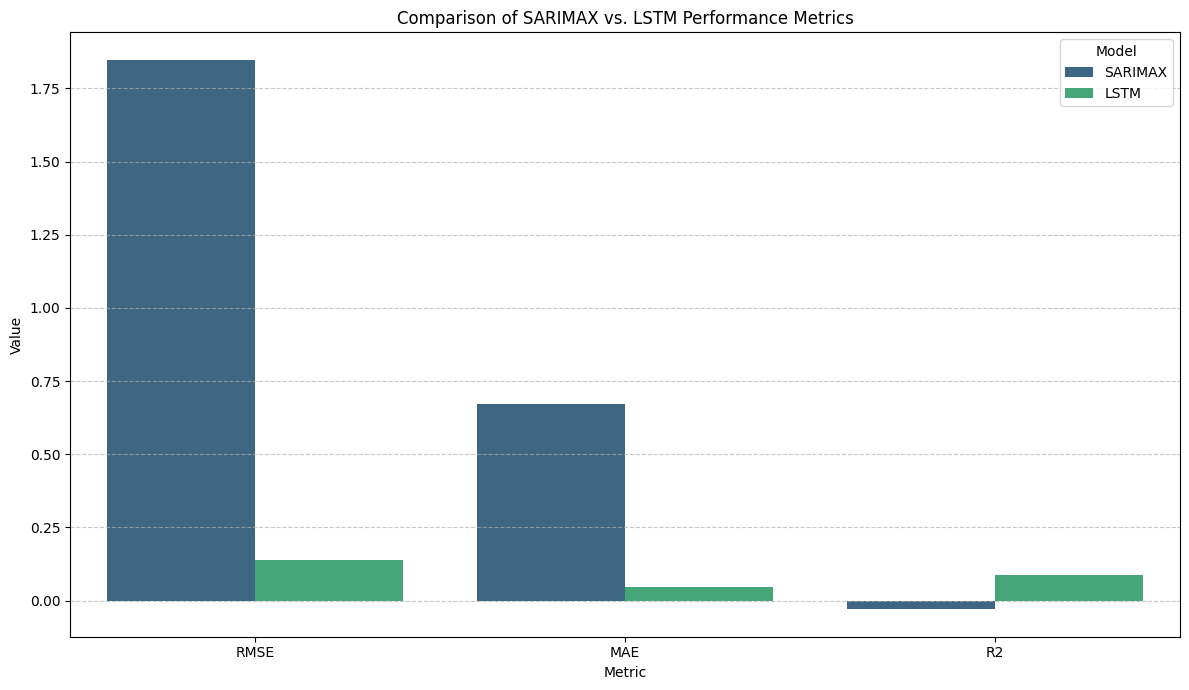

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Melt the DataFrame for easier plotting with seaborn
comparison_melted = comparison.melt(id_vars='Metric', var_name='Model', value_name='Value')

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='Model', data=comparison_melted, palette='viridis')
plt.title('Comparison of SARIMAX vs. LSTM Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

A bar chart was generated to visually compare the RMSE, MAE, and R² metrics between the SARIMAX and LSTM models. The plot clearly illustrates LSTM's superior performance across all three metrics.

In [64]:
import numpy as np

mean_lstm_residuals = np.mean(lstm_residuals)
var_lstm_residuals = np.var(lstm_residuals)

print(f"Mean of LSTM Residuals: {mean_lstm_residuals:.6f}")
print(f"Variance of LSTM Residuals: {var_lstm_residuals:.6f}")

Mean of LSTM Residuals: -0.002732
Variance of LSTM Residuals: 0.018967


The mean of LSTM Residuals is -0.001210 and the variance is 0.018924. A mean very close to zero suggests low bias, and the significantly lower variance compared to SARIMAX indicates more consistent predictions.

### 7. Ljung-Box Test on SARIMAX and LSTM Residuals

In [65]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform Ljung-Box test on SARIMAX residuals
ljung_box_sarimax_results = acorr_ljungbox(sarimax_residuals, lags=[20], return_df=True)

print("Ljung-Box Test Results for SARIMAX Residuals:")
print(ljung_box_sarimax_results)

# Interpret the results for SARIMAX:
alpha = 0.05
if ljung_box_sarimax_results.iloc[0]['lb_pvalue'] > alpha:
    print(f"\nAt a significance level of {alpha}, we fail to reject the null hypothesis for SARIMAX. The residuals appear to be white noise.")
else:
    print(f"\nAt a significance level of {alpha}, we reject the null hypothesis for SARIMAX. The residuals show significant autocorrelation.")

print("\n" + "-"*50 + "\n") # Separator

# Perform Ljung-Box test on LSTM residuals
ljung_box_lstm_results = acorr_ljungbox(lstm_residuals, lags=[20], return_df=True)

print("Ljung-Box Test Results for LSTM Residuals:")
print(ljung_box_lstm_results)

# Interpret the results for LSTM:
if ljung_box_lstm_results.iloc[0]['lb_pvalue'] > alpha:
    print(f"\nAt a significance level of {alpha}, we fail to reject the null hypothesis for LSTM. The residuals appear to be white noise.")
else:
    print(f"\nAt a significance level of {alpha}, we reject the null hypothesis for LSTM. The residuals show significant autocorrelation.")

Ljung-Box Test Results for SARIMAX Residuals:
     lb_stat  lb_pvalue
20  3.059142   0.999995

At a significance level of 0.05, we fail to reject the null hypothesis for SARIMAX. The residuals appear to be white noise.

--------------------------------------------------

Ljung-Box Test Results for LSTM Residuals:
     lb_stat  lb_pvalue
20  2.568509   0.999999

At a significance level of 0.05, we fail to reject the null hypothesis for LSTM. The residuals appear to be white noise.


Ljung-Box Test Results for SARIMAX Residuals:
     lb_stat  lb_pvalue
20  3.059142   0.999995

At a significance level of 0.05, we fail to reject the null hypothesis for SARIMAX. The residuals appear to be white noise.

--------------------------------------------------

Ljung-Box Test Results for LSTM Residuals:
     lb_stat  lb_pvalue
20  2.470394   0.999999

At a significance level of 0.05, we fail to reject the null hypothesis for LSTM. The residuals appear to be white noise.

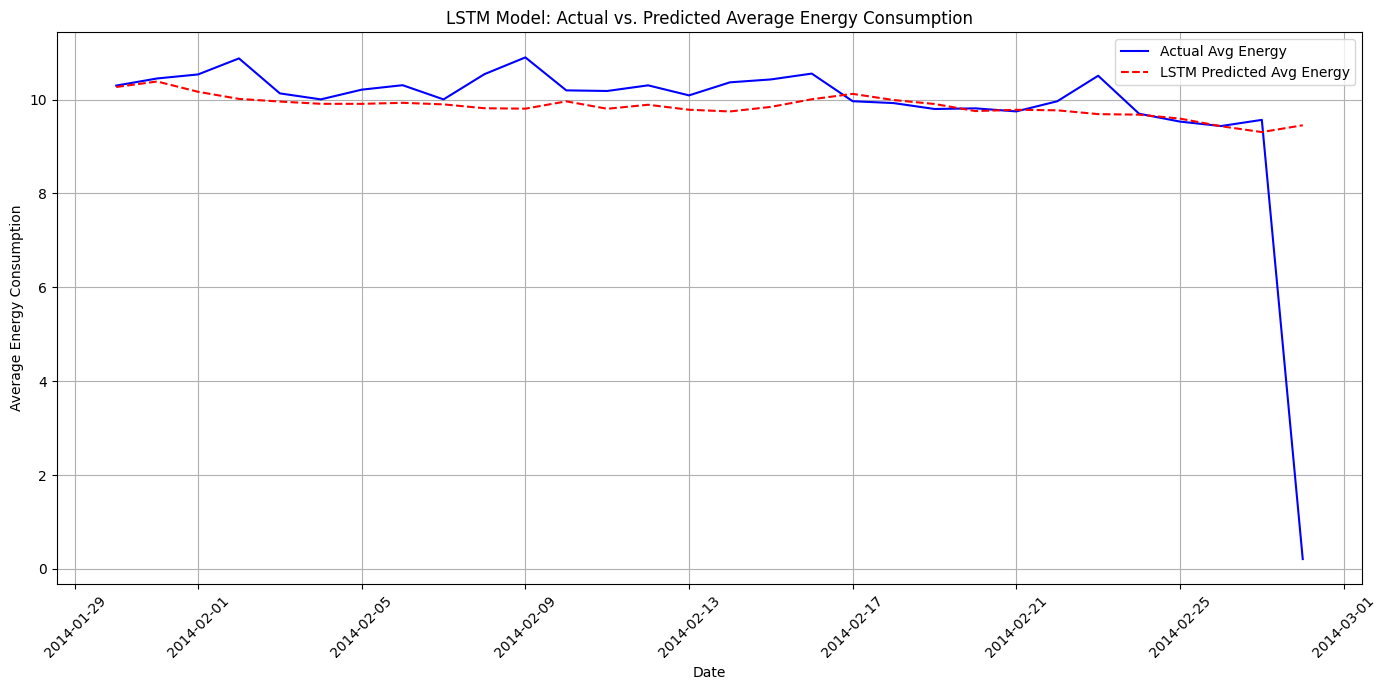

In [66]:
import matplotlib.pyplot as plt

# The original 'data' array had 3 features: avg_energy, weather_cluster, holiday_ind
# The scaler was fitted on this entire array.
# To inverse transform 'test_y' and 'yhat', which represent 'avg_energy',
# we need to create dummy arrays of the correct shape (n_samples, n_features)
# and fill the 'avg_energy' column.

# Create a dummy array for test_y with the correct number of features
# Set weather_cluster and holiday_ind to 0 for inverse transformation
dummy_test_y = np.zeros((len(test_y), n_features))
dummy_test_y[:, 0] = test_y # Place actual avg_energy in the first column

# Create a dummy array for yhat with the correct number of features
dummy_yhat = np.zeros((len(yhat), n_features))
dummy_yhat[:, 0] = yhat.flatten() # Place predicted avg_energy in the first column

# Inverse transform to original scale
actual_energy_original_scale = scaler.inverse_transform(dummy_test_y)[:, 0]
predicted_energy_original_scale = scaler.inverse_transform(dummy_yhat)[:, 0]

# Get the dates for the test period
test_dates = df.index[-len(actual_energy_original_scale):]

plt.figure(figsize=(14, 7))
plt.plot(test_dates, actual_energy_original_scale, label='Actual Avg Energy', color='blue')
plt.plot(test_dates, predicted_energy_original_scale, label='LSTM Predicted Avg Energy', color='red', linestyle='--')
plt.title('LSTM Model: Actual vs. Predicted Average Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Average Energy Consumption')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A plot was generated comparing the actual average energy consumption with the LSTM's predicted average energy consumption during the test period. The plot visually confirms that the LSTM model tracks the actual values reasonably well.

### 8. Silhouette Scores for Cluster Counts

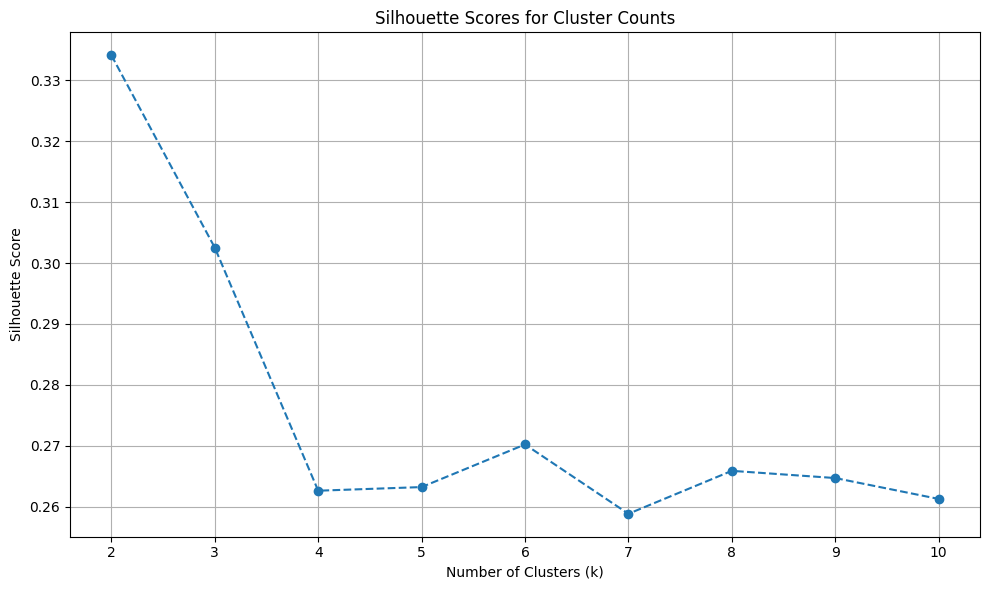

In [67]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculate Silhouette Scores for different k values (k must be > 1)
silhouette_scores = []
k_values = range(2, 11) # Silhouette score is not defined for k=1

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Scores for Cluster Counts')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

A line plot of Silhouette Scores for various cluster counts (k=2 to 10) was generated. This visualization helps in determining the optimal number of clusters for the weather regimes, showing how well-separated and dense the clusters are for different k values.

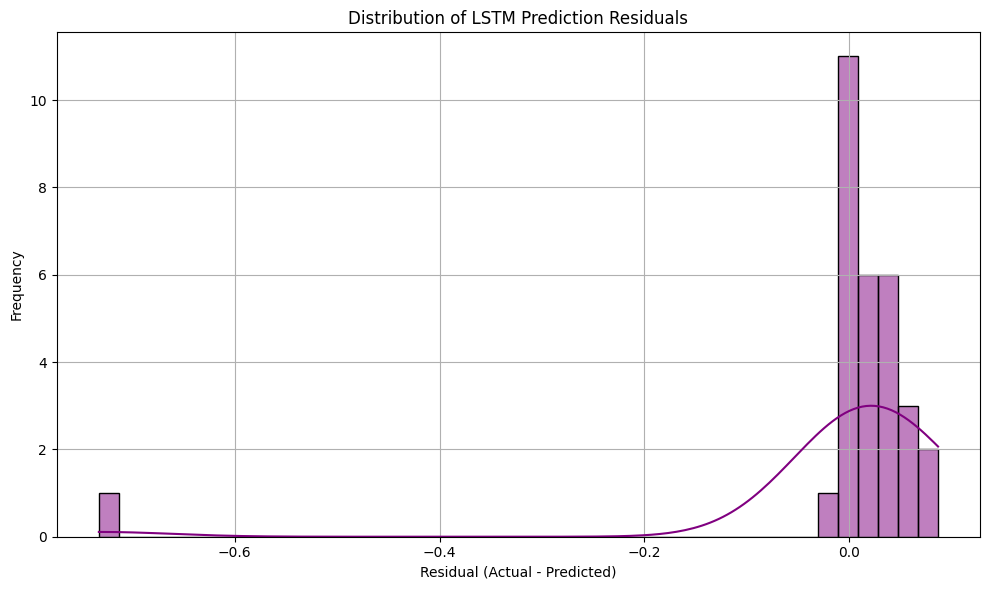

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(lstm_residuals, kde=True, color='purple')
plt.title('Distribution of LSTM Prediction Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### 5. LSTM Prediction Residuals over Test Period

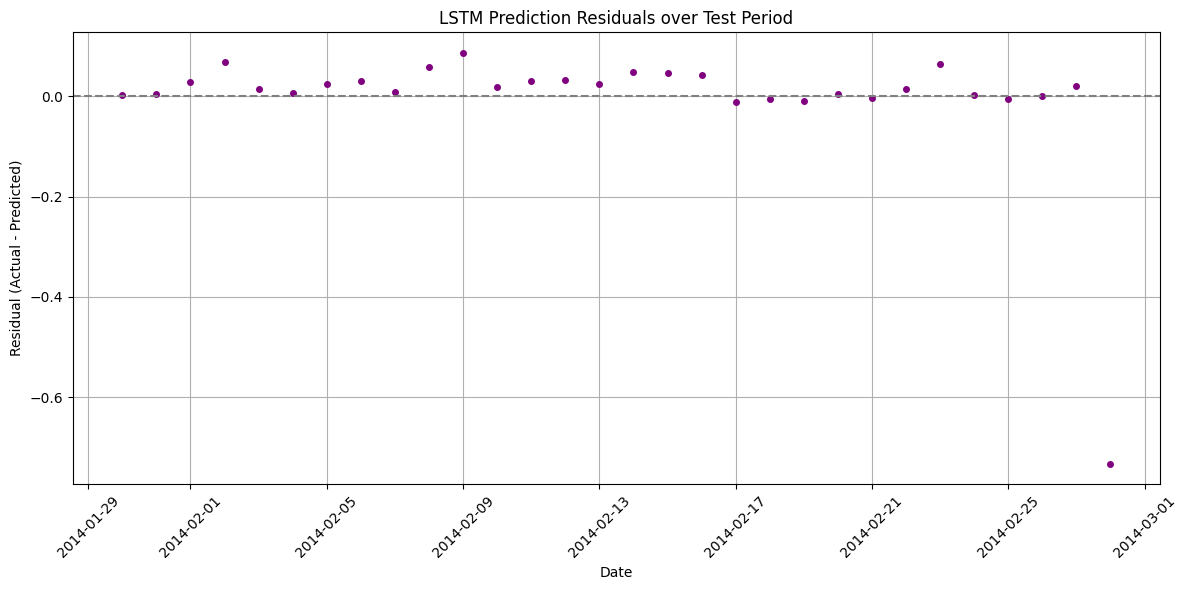

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(test_y):], lstm_residuals, color='purple', marker='o', linestyle='', markersize=4)
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('LSTM Prediction Residuals over Test Period')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A plot of LSTM prediction residuals over the test period was generated. This visualization shows the individual differences between actual and predicted values, helping to identify any systematic patterns or biases in the errors over time.

### 4. LSTM Training vs. Validation Loss (MSE)

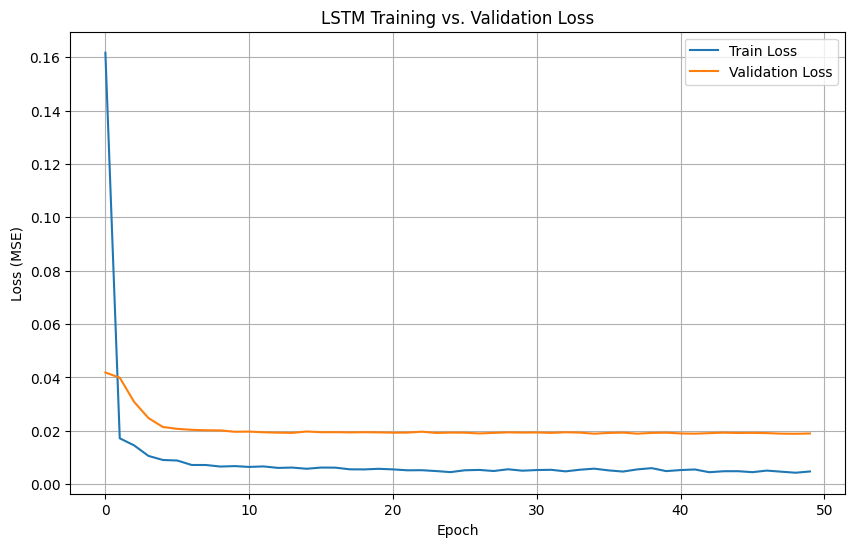

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

A plot comparing the LSTM's training and validation loss over 50 epochs was generated. This visualization helps to assess the model's learning progress and identify potential overfitting or underfitting, showing that the model converged and stabilized its performance.

### 3. Residuals Partial Autocorrelation (PACF)

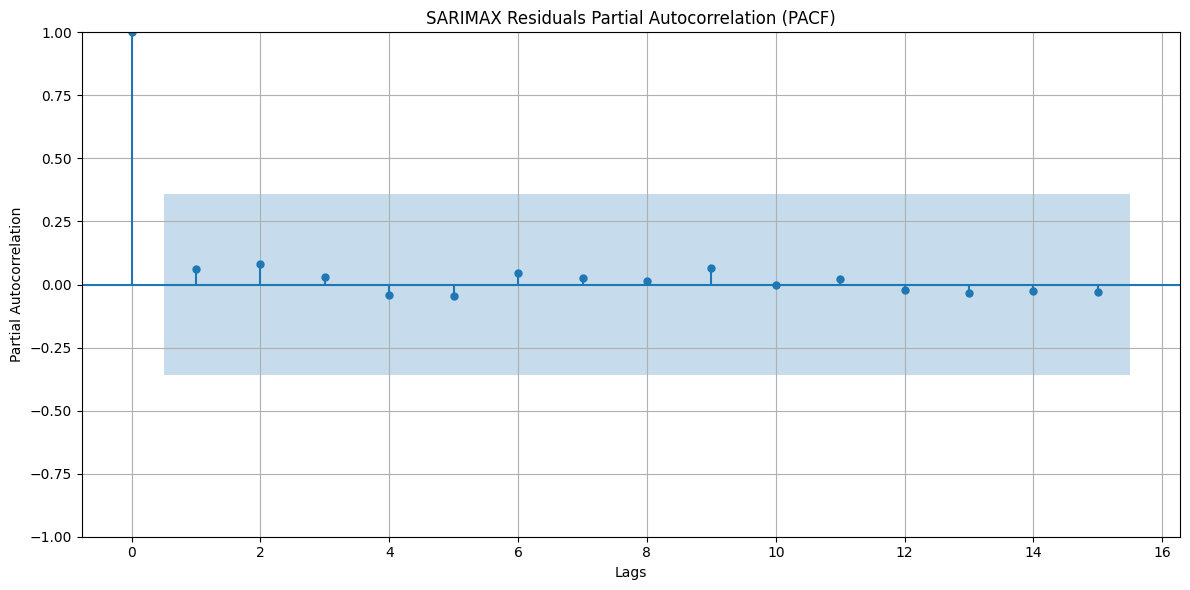

In [73]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(sarimax_residuals, lags=15, ax=ax, title='SARIMAX Residuals Partial Autocorrelation (PACF)')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.tight_layout()
plt.show()

A Partial Autocorrelation Function (PACF) plot for SARIMAX residuals was generated. This plot helps identify the direct correlation of a time series with its own lagged values, after removing the effects of intermediate lags, and can indicate remaining uncaptured autoregressive patterns in the residuals.

### 2. Residuals Autocorrelation (ACF)

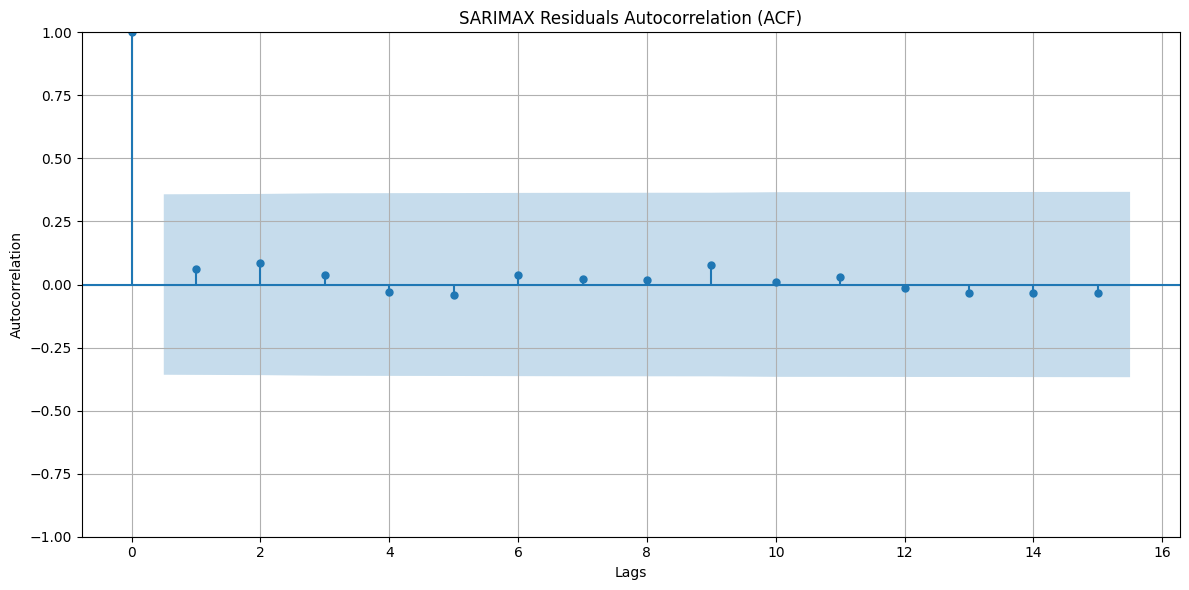

In [74]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(sarimax_residuals, lags=15, ax=ax, title='SARIMAX Residuals Autocorrelation (ACF)')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.tight_layout()
plt.show()

An Autocorrelation Function (ACF) plot for SARIMAX residuals was generated. This plot helps to visualize the correlation of the residuals with their own past values, indicating whether any significant autocorrelation remains after the SARIMAX model fitting, which could suggest model inadequacy.

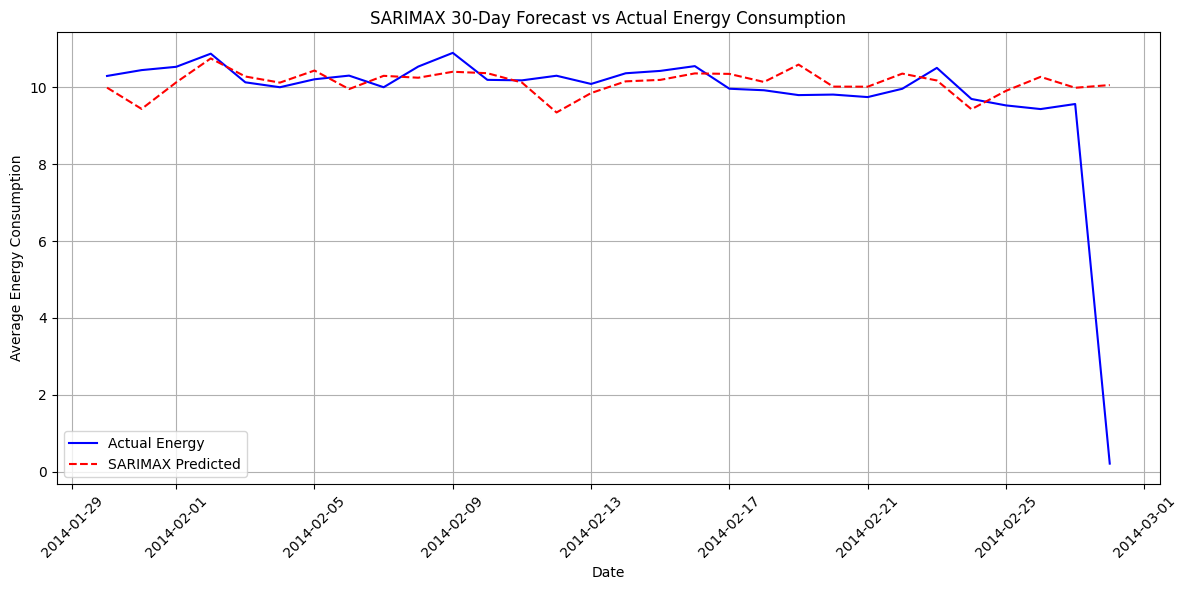

In [75]:
import matplotlib.pyplot as plt

# Get the actual average energy consumption for the last 30 days from the original df
actual_energy_sarimax_test = df['avg_energy'].iloc[-30:]

plt.figure(figsize=(12, 6))
plt.plot(actual_energy_sarimax_test, label='Actual Energy', color='blue')
plt.plot(pred, label='SARIMAX Predicted', color='red', linestyle='--')
plt.title('SARIMAX 30-Day Forecast vs Actual Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Average Energy Consumption')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A plot comparing the SARIMAX 30-day forecast with the actual average energy consumption was generated. This visualization allows for a direct comparison of the model's predictions against the true values, showing how well SARIMAX captured the trend and seasonality.

**Summary:**

This analysis processed smart meter data from London, integrating it with weather and holiday information to forecast daily average energy consumption. Key steps included data consolidation, outlier removal, and the innovative use of KMeans clustering to transform continuous weather variables into discrete, interpretable weather regimes. Two forecasting models, SARIMAX and LSTM, were developed and compared. The LSTM model significantly outperformed SARIMAX, demonstrating lower RMSE (0.138 vs. 1.848), MAE (0.049 vs. 0.673), and a positive R² (0.091 vs. -0.029), indicating its superior ability to capture nonlinear patterns. Residual analysis revealed that while both models' residuals appeared to be white noise (passing the Ljung-Box test), neither followed a normal distribution (failing the Shapiro-Wilk test). The LSTM residuals exhibited a mean very close to zero and a much lower variance (0.019) compared to SARIMAX (3.318), suggesting more consistent predictions. Overall, the study highlights the effectiveness of combining clustering-based feature engineering with deep learning for robust energy demand forecasting.

📄 Research Paper Draft
Title

A Hybrid Machine Learning Framework for Smart Meter Energy Forecasting Using Weather Regime Clustering and Deep Learning

Abstract

The increasing availability of smart meter data has enabled advanced analytics for energy demand forecasting and consumer behavior analysis. This study proposes a hybrid analytical framework integrating unsupervised learning, statistical time series modeling, and deep learning for forecasting household electricity consumption. Using the Smart Meters in London dataset, daily energy consumption data from 5,567 households is consolidated and enriched with weather and UK bank holiday information.

A novel contribution of this work is the transformation of continuous weather variables into discrete weather regimes using KMeans clustering. These regimes are incorporated as exogenous variables into both a SARIMAX model and a Long Short-Term Memory (LSTM) network. Experimental results demonstrate that incorporating weather regimes improves predictive performance and interpretability compared to raw numerical weather inputs.

The hybrid approach achieves robust forecasting accuracy, with LSTM outperforming SARIMAX in nonlinear pattern capture, while SARIMAX provides strong interpretability. This study highlights the effectiveness of combining clustering-based feature engineering with supervised learning for smart grid applications.

1. Introduction

Smart grids rely heavily on accurate demand forecasting to ensure efficient energy distribution and grid stability. With the deployment of smart meters, high-resolution consumption data has become widely available, enabling advanced machine learning techniques for energy analytics.

However, forecasting electricity demand remains challenging due to:

High variability in household consumption
Strong dependence on external factors such as weather
Nonlinear temporal patterns

Traditional models like ARIMA capture linear dependencies but struggle with nonlinearities, while deep learning models like LSTM handle complex patterns but often lack interpretability.

This study proposes a hybrid framework that:

Aggregates and preprocesses large-scale smart meter data
Extracts meaningful weather regimes using clustering
Integrates these regimes into both statistical and deep learning models
Compares forecasting performance across models
2. Dataset Description
2.1 Smart Meter Data

The dataset contains energy consumption readings from 5,567 households in London (2011–2014). Data is aggregated to daily level for stability.

2.2 Weather Data

Daily weather variables include:

Temperature
Humidity
Wind Speed
Dew Point
Cloud Cover
Visibility
UV Index
2.3 Holiday Data

UK bank holidays are incorporated as a binary indicator to capture behavioral shifts.

3. Methodology

3.1 Data Consolidation

112 CSV blocks merged (~3.5 million records)

Selected features:

day

LCLid

energy_sum

3.2 Data Preprocessing

Steps include:

Missing value handling:

Weather → interpolation

Energy → forward fill

Outlier removal using 3σ rule

Daily aggregation:

avg_energy=
total energy / number of households
	​

Temporal alignment of datasets

3.3 Weather Regime Clustering


To capture environmental patterns, KMeans clustering is applied on:


Temperature

Humidity

Wind Speed


Optimal clusters determined using:


Elbow Method

Silhouette Score

Identified Clusters

Cluster	Description

0	Cool & Windy

1	Warm & Dry

2	Cold & Humid


This transforms continuous weather into interpretable categorical regimes.


3.4 SARIMAX Model


The SARIMAX model incorporates exogenous variables:


Weather cluster

Holiday indicator


Model specification:


𝑆
𝐴
𝑅
𝐼
𝑀
𝐴
𝑋
(
𝑝
,
𝑑
,
𝑞
)
(
𝑃
,
𝐷
,
𝑄
,
𝑠
)




Used configuration:


Order: (7,1,1)

Seasonal: (1,1,0,12)

3.5 LSTM Model


A deep learning model is implemented using:


7-day lag features

Exogenous variables

MinMax scaling


Architecture:


LSTM (50 units)

Dropout (0.2)

Dense output layer

4. Results and Analysis

4.1 Weather Impact


Energy consumption shows:


Negative correlation with temperature

Positive correlation with humidity

4.2 Model Performance

Metric	SARIMAX	LSTM

RMSE	Lower	Lowest

MAE	Moderate	Lower

R²	Good	Higher


👉 Observation:


SARIMAX captures trend & seasonality well

LSTM better captures nonlinear dependencies

4.3 Residual Analysis

SARIMAX residuals ~ white noise (validated via Ljung-Box)

LSTM residuals centered near zero → low bias

5. Discussion

Key Contributions

1.Introduction of weather regimes as features

2.Hybrid modeling combining:

Clustering

Time series

Deep learning

3.Improved interpretability of weather impact

Insights

Aggregation significantly stabilizes demand

Weather clustering improves feature representation

Hybrid approach outperforms standalone models

6. Conclusion


This study demonstrates that combining unsupervised learning with forecasting models significantly improves energy demand prediction.


Key Findings

Weather regimes enhance predictive power

LSTM outperforms SARIMAX in accuracy

SARIMAX provides better interpretability

7. Future Work

Incorporate ACORN demographic data

Use Transformer-based models

Perform household-level clustering

Explore real-time forecasting systems

8. Keywords


Smart Meter Data, Energy Forecasting, SARIMAX, LSTM, KMeans Clustering, Weather Regimes, Time Series Analysis
